# Final Project Pembelajaran Mesin 2
## Plant Disease Detection Menggunakan Lightweight Deep Learning dengan Transfer Learning

**Nama:** Farrel Ghozy Affifudin — **NIM:** 452024611053 — **Kelas:** TI5 A2
**Universitas:** Universitas Darussalam Gontor

**Dataset:** PlantVillage (Kaggle) — 38 kelas, 54.305 citra daun
**Hardware:** NVIDIA RTX 4060 (CUDA 12.4, mixed precision FP16) · PyTorch 2.6

Notebook ini berisi **seluruh pipeline eksperimen**: verifikasi dataset, training 4 skenario
(E1 baseline CNN, E2 MobileNetV3 frozen, E3 EfficientNet frozen, E4 MobileNetV3 fine-tune),
evaluasi test set, dan error analysis. Semua hasil di bawah adalah eksekusi nyata.
Skrip pendukung: `v2/scripts/` (common.py, prepare_data.py, run_experiment.py).


## 1. Setup & Konfigurasi

In [1]:
import os, sys, json, glob, time, copy, datetime
import numpy as np
import torch
import torch.nn as nn

# load skrip pendukung (v2/scripts/common.py) — skrip lama, dipakai ulang
sys.path.insert(0, 'v2/scripts')
from common import (set_seed, make_loaders, build_model, freeze_backbone,
                    count_parameters, evaluate_model, save_json,
                    plot_history, plot_confusion_matrix,
                    save_classification_report)

print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM total: %.1f GB' % (torch.cuda.get_device_properties(0).total_memory / 1e9))

EXPERIMENTS = {
    'e1': dict(name='e1_custom_cnn', pretrained=False, freeze=False, lr=1e-3, epochs=15,
               desc='Custom CNN baseline (from scratch)'),
    'e2': dict(name='e2_mobilenetv3', pretrained=True, freeze=True, lr=1e-3, epochs=12,
               desc='MobileNetV3-Small TL, backbone frozen'),
    'e3': dict(name='e3_efficientnet', pretrained=True, freeze=True, lr=1e-3, epochs=12,
               desc='EfficientNet-B0 TL, backbone frozen'),
    'e4': dict(name='e4_mobilenetv3_ft', pretrained=True, freeze=False, lr=1e-4, epochs=12,
               desc='MobileNetV3-Small TL, fine-tune penuh'),
}
SEED = 42
BATCH = 32
DATA_ROOT = os.path.expanduser('~/pm2_v2/data/plantvillage_split')
OUT_ROOT = 'v2/results'      # hasil disimpan di repo (bukti training)
MODEL_ROOT = os.path.expanduser('~/pm2_v2/models')
set_seed(SEED)
print('\nSeed:', SEED, '| Batch:', BATCH)
print('Data:', DATA_ROOT)
print('Output:', OUT_ROOT)

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4060
VRAM total: 8.6 GB

Seed: 42 | Batch: 32
Data: /home/master_core_ti/pm2_v2/data/plantvillage_split
Output: v2/results


## 2. Dataset PlantVillage

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.datasets import ImageFolder

if os.path.isdir(DATA_ROOT):
    tr = ImageFolder(f'{DATA_ROOT}/train')
    va = ImageFolder(f'{DATA_ROOT}/val')
    te = ImageFolder(f'{DATA_ROOT}/test')
    print(f'Kelas: {len(tr.classes)}')
    print(f'Train: {len(tr.samples)} | Val: {len(va.samples)} | Test: {len(te.samples)}')
    print('\nDaftar kelas:')
    for i, c in enumerate(tr.classes):
        n = sum(1 for p, _ in tr.samples if tr.classes.index(c) == i)
        print(f'  {i+1:2d}. {c}  ({n} train)')
    print('\n=== Contoh citra per kelas (3 kelas pertama) ===')
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for row in range(3):
        cls = tr.classes[row]
        paths = [p for p, l in tr.samples if l == row][:3]
        for col, p in enumerate(paths):
            img = mpimg.imread(p)
            axes[row, col].imshow(img)
            axes[row, col].axis('off')
            if col == 0: axes[row, col].set_title(cls, fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print('Dataset tidak ditemukan di', DATA_ROOT)
    print('Download: kaggle datasets download -d abdallahalidev/plantvillage-dataset,')
    print('lalu jalankan: python3 v2/scripts/prepare_data.py')

Kelas: 38
Train: 43429 | Val: 5417 | Test: 5459

Daftar kelas:
   1. Apple___Apple_scab  (43429 train)
   2. Apple___Black_rot  (43429 train)
   3. Apple___Cedar_apple_rust  (43429 train)
   4. Apple___healthy  (43429 train)
   5. Blueberry___healthy  (43429 train)
   6. Cherry_(including_sour)___Powdery_mildew  (43429 train)
   7. Cherry_(including_sour)___healthy  (43429 train)
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  (43429 train)
   9. Corn_(maize)___Common_rust_  (43429 train)
  10. Corn_(maize)___Northern_Leaf_Blight  (43429 train)
  11. Corn_(maize)___healthy  (43429 train)
  12. Grape___Black_rot  (43429 train)
  13. Grape___Esca_(Black_Measles)  (43429 train)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)  (43429 train)
  15. Grape___healthy  (43429 train)
  16. Orange___Haunglongbing_(Citrus_greening)  (43429 train)
  17. Peach___Bacterial_spot  (43429 train)
  18. Peach___healthy  (43429 train)
  19. Pepper,_bell___Bacterial_spot  (43429 train)
  20. Peppe

  38. Tomato___healthy  (43429 train)

=== Contoh citra per kelas (3 kelas pertama) ===


## 3.1 Eksperimen E1 — Custom CNN baseline (from scratch)

In [3]:
cfg = EXPERIMENTS['e1']
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
out_dir = os.path.join(OUT_ROOT, 'e1')
os.makedirs(out_dir, exist_ok=True)
os.makedirs(MODEL_ROOT, exist_ok=True)

train_loader, val_loader, test_loader, class_names = make_loaders(
    DATA_ROOT, BATCH, num_workers=6, seed=SEED)
num_classes = len(class_names)
print(f'Kelas: {num_classes} | train={len(train_loader.dataset)} val={len(val_loader.dataset)} test={len(test_loader.dataset)}')

model = build_model(cfg['name'], num_classes, pretrained=cfg['pretrained'])
freeze_backbone(model, cfg['freeze'])
model = model.to(device)
total_p, train_p = count_parameters(model)
print(f'Param total: {total_p:,} | trainable: {train_p:,}')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=True)

best_val_loss = float('inf'); best_state = None; early_cnt = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
t0 = time.time()

for epoch in range(1, cfg['epochs'] + 1):
    model.train(); rl, rc, tot = 0.0, 0, 0
    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        rl += loss.item() * x.size(0); rc += (out.argmax(1) == y).sum().item(); tot += x.size(0)
    tr_loss, tr_acc = rl / tot, rc / tot

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(x); loss = criterion(out, y)
            vl += loss.item() * x.size(0); vc += (out.argmax(1) == y).sum().item(); vt += x.size(0)
    va_loss, va_acc = vl / vt, vc / vt
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    print(f'Epoch {epoch:02d}/{cfg["epochs"]} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss; best_state = copy.deepcopy(model.state_dict()); early_cnt = 0
    else:
        early_cnt += 1
        if early_cnt >= 4:
            print(f'Early stopping @ epoch {epoch}'); break

train_secs = time.time() - t0
model.load_state_dict(best_state)
print(f'\nTraining selesai dalam {train_secs:.0f} detik ({train_secs/60:.1f} menit), best val_loss={best_val_loss:.4f}')

# ---- evaluasi test set ----
res = evaluate_model(model, test_loader, device, num_classes)
metrics = {
    'experiment': 'e1', 'description': cfg['desc'], 'model': cfg['name'],
    'config': {'epochs': cfg['epochs'], 'batch': BATCH, 'lr': cfg['lr'], 'optimizer': 'Adam',
               'loss': 'CrossEntropyLoss', 'pretrained': cfg['pretrained'],
               'freeze_backbone': cfg['freeze'], 'augmentation': True,
               'early_stopping_patience': 4, 'seed': SEED,
               'best_epoch': len(history['train_loss'])},
    'train_seconds': train_secs, 'best_val_loss': float(best_val_loss),
    'test': {k: v for k, v in res.items() if k in ('accuracy','precision_macro','recall_macro','f1_macro')},
    'per_class': {'classes': class_names, 'precision': res['per_class_precision'],
                   'recall': res['per_class_recall'], 'f1': res['per_class_f1']},
    'params': {'total': total_p, 'trainable': train_p},
    'class_names': class_names, 'run_time': datetime.datetime.now().isoformat(),
}
save_json(metrics, os.path.join(out_dir, 'metrics.json'))
save_json(history, os.path.join(out_dir, 'history.json'))
plot_history(history, os.path.join(out_dir, 'training_curves.png'))
plot_confusion_matrix(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'confusion_matrix.png'))
save_classification_report(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'classification_report.txt'))

# error analysis
mis = np.where(res['y_true'] != res['y_pred'])[0]
conf = res['probs'].max(axis=1)
order = mis[np.argsort(conf[mis])]
errors = [{'path': res['paths'][i], 'true': class_names[res['y_true'][i]],
            'pred': class_names[res['y_pred'][i]], 'confidence': float(conf[i])} for i in order[:25]]
save_json(errors, os.path.join(out_dir, 'top_errors.json'))
per_acc = {class_names[c]: float((res['y_pred'][res['y_true']==c] == c).mean()) for c in range(num_classes)}
save_json({'worst': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: kv[1])[:10]],
           'best': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: -kv[1])[:10]]},
          os.path.join(out_dir, 'per_class_analysis.json'))
torch.save(best_state, os.path.join(MODEL_ROOT, 'e1_best.pt'))

t = metrics['test']
print('\n=== HASIL TEST SET ===')
print(f'Accuracy: {t["accuracy"]:.4f} | Precision: {t["precision_macro"]:.4f} | Recall: {t["recall_macro"]:.4f} | F1: {t["f1_macro"]:.4f}')

Kelas: 38 | train=43429 val=5417 test=5459
Param total: 540,454 | trainable: 540,454


Epoch 01/15 | train_loss=1.7164 train_acc=0.5001 | val_loss=1.3168 val_acc=0.6186 | lr=1.00e-03


Epoch 02/15 | train_loss=1.0150 train_acc=0.6799 | val_loss=1.1190 val_acc=0.7032 | lr=1.00e-03


Epoch 03/15 | train_loss=0.7713 train_acc=0.7516 | val_loss=0.6197 val_acc=0.8032 | lr=1.00e-03


Epoch 04/15 | train_loss=0.6332 train_acc=0.7960 | val_loss=0.7896 val_acc=0.7639 | lr=1.00e-03


...

Epoch 12/15 | train_loss=0.2504 train_acc=0.9174 | val_loss=0.1602 val_acc=0.9479 | lr=1.00e-03


Epoch 13/15 | train_loss=0.2311 train_acc=0.9236 | val_loss=0.3489 val_acc=0.8879 | lr=1.00e-03


Epoch 14/15 | train_loss=0.2228 train_acc=0.9266 | val_loss=0.1351 val_acc=0.9566 | lr=1.00e-03


Epoch 15/15 | train_loss=0.2114 train_acc=0.9311 | val_loss=0.2130 val_acc=0.9341 | lr=1.00e-03

Training selesai dalam 717 detik (11.9 menit), best val_loss=0.1351



=== HASIL TEST SET ===
Accuracy: 0.9509 | Precision: 0.9485 | Recall: 0.9317 | F1: 0.9339


## 3.2 Eksperimen E2 — MobileNetV3-Small TL, backbone frozen

In [4]:
cfg = EXPERIMENTS['e2']
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
out_dir = os.path.join(OUT_ROOT, 'e2')
os.makedirs(out_dir, exist_ok=True)
os.makedirs(MODEL_ROOT, exist_ok=True)

train_loader, val_loader, test_loader, class_names = make_loaders(
    DATA_ROOT, BATCH, num_workers=6, seed=SEED)
num_classes = len(class_names)
print(f'Kelas: {num_classes} | train={len(train_loader.dataset)} val={len(val_loader.dataset)} test={len(test_loader.dataset)}')

model = build_model(cfg['name'], num_classes, pretrained=cfg['pretrained'])
freeze_backbone(model, cfg['freeze'])
model = model.to(device)
total_p, train_p = count_parameters(model)
print(f'Param total: {total_p:,} | trainable: {train_p:,}')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=True)

best_val_loss = float('inf'); best_state = None; early_cnt = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
t0 = time.time()

for epoch in range(1, cfg['epochs'] + 1):
    model.train(); rl, rc, tot = 0.0, 0, 0
    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        rl += loss.item() * x.size(0); rc += (out.argmax(1) == y).sum().item(); tot += x.size(0)
    tr_loss, tr_acc = rl / tot, rc / tot

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(x); loss = criterion(out, y)
            vl += loss.item() * x.size(0); vc += (out.argmax(1) == y).sum().item(); vt += x.size(0)
    va_loss, va_acc = vl / vt, vc / vt
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    print(f'Epoch {epoch:02d}/{cfg["epochs"]} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss; best_state = copy.deepcopy(model.state_dict()); early_cnt = 0
    else:
        early_cnt += 1
        if early_cnt >= 4:
            print(f'Early stopping @ epoch {epoch}'); break

train_secs = time.time() - t0
model.load_state_dict(best_state)
print(f'\nTraining selesai dalam {train_secs:.0f} detik ({train_secs/60:.1f} menit), best val_loss={best_val_loss:.4f}')

# ---- evaluasi test set ----
res = evaluate_model(model, test_loader, device, num_classes)
metrics = {
    'experiment': 'e2', 'description': cfg['desc'], 'model': cfg['name'],
    'config': {'epochs': cfg['epochs'], 'batch': BATCH, 'lr': cfg['lr'], 'optimizer': 'Adam',
               'loss': 'CrossEntropyLoss', 'pretrained': cfg['pretrained'],
               'freeze_backbone': cfg['freeze'], 'augmentation': True,
               'early_stopping_patience': 4, 'seed': SEED,
               'best_epoch': len(history['train_loss'])},
    'train_seconds': train_secs, 'best_val_loss': float(best_val_loss),
    'test': {k: v for k, v in res.items() if k in ('accuracy','precision_macro','recall_macro','f1_macro')},
    'per_class': {'classes': class_names, 'precision': res['per_class_precision'],
                   'recall': res['per_class_recall'], 'f1': res['per_class_f1']},
    'params': {'total': total_p, 'trainable': train_p},
    'class_names': class_names, 'run_time': datetime.datetime.now().isoformat(),
}
save_json(metrics, os.path.join(out_dir, 'metrics.json'))
save_json(history, os.path.join(out_dir, 'history.json'))
plot_history(history, os.path.join(out_dir, 'training_curves.png'))
plot_confusion_matrix(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'confusion_matrix.png'))
save_classification_report(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'classification_report.txt'))

# error analysis
mis = np.where(res['y_true'] != res['y_pred'])[0]
conf = res['probs'].max(axis=1)
order = mis[np.argsort(conf[mis])]
errors = [{'path': res['paths'][i], 'true': class_names[res['y_true'][i]],
            'pred': class_names[res['y_pred'][i]], 'confidence': float(conf[i])} for i in order[:25]]
save_json(errors, os.path.join(out_dir, 'top_errors.json'))
per_acc = {class_names[c]: float((res['y_pred'][res['y_true']==c] == c).mean()) for c in range(num_classes)}
save_json({'worst': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: kv[1])[:10]],
           'best': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: -kv[1])[:10]]},
          os.path.join(out_dir, 'per_class_analysis.json'))
torch.save(best_state, os.path.join(MODEL_ROOT, 'e2_best.pt'))

t = metrics['test']
print('\n=== HASIL TEST SET ===')
print(f'Accuracy: {t["accuracy"]:.4f} | Precision: {t["precision_macro"]:.4f} | Recall: {t["recall_macro"]:.4f} | F1: {t["f1_macro"]:.4f}')

Kelas: 38 | train=43429 val=5417 test=5459
Param total: 1,556,806 | trainable: 629,798


Epoch 01/12 | train_loss=0.4773 train_acc=0.8552 | val_loss=0.2319 val_acc=0.9258 | lr=1.00e-03


Epoch 02/12 | train_loss=0.2634 train_acc=0.9125 | val_loss=0.2067 val_acc=0.9356 | lr=1.00e-03


Epoch 03/12 | train_loss=0.2298 train_acc=0.9242 | val_loss=0.1772 val_acc=0.9441 | lr=1.00e-03


Epoch 04/12 | train_loss=0.2089 train_acc=0.9311 | val_loss=0.1537 val_acc=0.9483 | lr=1.00e-03


...

Epoch 09/12 | train_loss=0.1170 train_acc=0.9610 | val_loss=0.1243 val_acc=0.9596 | lr=5.00e-04


Epoch 10/12 | train_loss=0.1131 train_acc=0.9612 | val_loss=0.1210 val_acc=0.9616 | lr=5.00e-04


Epoch 11/12 | train_loss=0.1127 train_acc=0.9628 | val_loss=0.1141 val_acc=0.9629 | lr=2.50e-04


Epoch 12/12 | train_loss=0.0872 train_acc=0.9707 | val_loss=0.0838 val_acc=0.9723 | lr=2.50e-04

Training selesai dalam 497 detik (8.3 menit), best val_loss=0.0838



=== HASIL TEST SET ===
Accuracy: 0.9747 | Precision: 0.9679 | Recall: 0.9618 | F1: 0.9641


## 3.3 Eksperimen E3 — EfficientNet-B0 TL, backbone frozen

In [5]:
cfg = EXPERIMENTS['e3']
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
out_dir = os.path.join(OUT_ROOT, 'e3')
os.makedirs(out_dir, exist_ok=True)
os.makedirs(MODEL_ROOT, exist_ok=True)

train_loader, val_loader, test_loader, class_names = make_loaders(
    DATA_ROOT, BATCH, num_workers=6, seed=SEED)
num_classes = len(class_names)
print(f'Kelas: {num_classes} | train={len(train_loader.dataset)} val={len(val_loader.dataset)} test={len(test_loader.dataset)}')

model = build_model(cfg['name'], num_classes, pretrained=cfg['pretrained'])
freeze_backbone(model, cfg['freeze'])
model = model.to(device)
total_p, train_p = count_parameters(model)
print(f'Param total: {total_p:,} | trainable: {train_p:,}')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=True)

best_val_loss = float('inf'); best_state = None; early_cnt = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
t0 = time.time()

for epoch in range(1, cfg['epochs'] + 1):
    model.train(); rl, rc, tot = 0.0, 0, 0
    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        rl += loss.item() * x.size(0); rc += (out.argmax(1) == y).sum().item(); tot += x.size(0)
    tr_loss, tr_acc = rl / tot, rc / tot

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(x); loss = criterion(out, y)
            vl += loss.item() * x.size(0); vc += (out.argmax(1) == y).sum().item(); vt += x.size(0)
    va_loss, va_acc = vl / vt, vc / vt
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    print(f'Epoch {epoch:02d}/{cfg["epochs"]} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss; best_state = copy.deepcopy(model.state_dict()); early_cnt = 0
    else:
        early_cnt += 1
        if early_cnt >= 4:
            print(f'Early stopping @ epoch {epoch}'); break

train_secs = time.time() - t0
model.load_state_dict(best_state)
print(f'\nTraining selesai dalam {train_secs:.0f} detik ({train_secs/60:.1f} menit), best val_loss={best_val_loss:.4f}')

# ---- evaluasi test set ----
res = evaluate_model(model, test_loader, device, num_classes)
metrics = {
    'experiment': 'e3', 'description': cfg['desc'], 'model': cfg['name'],
    'config': {'epochs': cfg['epochs'], 'batch': BATCH, 'lr': cfg['lr'], 'optimizer': 'Adam',
               'loss': 'CrossEntropyLoss', 'pretrained': cfg['pretrained'],
               'freeze_backbone': cfg['freeze'], 'augmentation': True,
               'early_stopping_patience': 4, 'seed': SEED,
               'best_epoch': len(history['train_loss'])},
    'train_seconds': train_secs, 'best_val_loss': float(best_val_loss),
    'test': {k: v for k, v in res.items() if k in ('accuracy','precision_macro','recall_macro','f1_macro')},
    'per_class': {'classes': class_names, 'precision': res['per_class_precision'],
                   'recall': res['per_class_recall'], 'f1': res['per_class_f1']},
    'params': {'total': total_p, 'trainable': train_p},
    'class_names': class_names, 'run_time': datetime.datetime.now().isoformat(),
}
save_json(metrics, os.path.join(out_dir, 'metrics.json'))
save_json(history, os.path.join(out_dir, 'history.json'))
plot_history(history, os.path.join(out_dir, 'training_curves.png'))
plot_confusion_matrix(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'confusion_matrix.png'))
save_classification_report(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'classification_report.txt'))

# error analysis
mis = np.where(res['y_true'] != res['y_pred'])[0]
conf = res['probs'].max(axis=1)
order = mis[np.argsort(conf[mis])]
errors = [{'path': res['paths'][i], 'true': class_names[res['y_true'][i]],
            'pred': class_names[res['y_pred'][i]], 'confidence': float(conf[i])} for i in order[:25]]
save_json(errors, os.path.join(out_dir, 'top_errors.json'))
per_acc = {class_names[c]: float((res['y_pred'][res['y_true']==c] == c).mean()) for c in range(num_classes)}
save_json({'worst': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: kv[1])[:10]],
           'best': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: -kv[1])[:10]]},
          os.path.join(out_dir, 'per_class_analysis.json'))
torch.save(best_state, os.path.join(MODEL_ROOT, 'e3_best.pt'))

t = metrics['test']
print('\n=== HASIL TEST SET ===')
print(f'Accuracy: {t["accuracy"]:.4f} | Precision: {t["precision_macro"]:.4f} | Recall: {t["recall_macro"]:.4f} | F1: {t["f1_macro"]:.4f}')

Kelas: 38 | train=43429 val=5417 test=5459
Param total: 4,056,226 | trainable: 48,678


Epoch 01/12 | train_loss=0.6522 train_acc=0.8470 | val_loss=0.2885 val_acc=0.9249 | lr=1.00e-03


Epoch 02/12 | train_loss=0.2937 train_acc=0.9148 | val_loss=0.2101 val_acc=0.9394 | lr=1.00e-03


Epoch 03/12 | train_loss=0.2530 train_acc=0.9222 | val_loss=0.1925 val_acc=0.9402 | lr=1.00e-03


Epoch 04/12 | train_loss=0.2319 train_acc=0.9263 | val_loss=0.1784 val_acc=0.9437 | lr=1.00e-03


...

Epoch 09/12 | train_loss=0.1962 train_acc=0.9364 | val_loss=0.1622 val_acc=0.9479 | lr=1.00e-03


Epoch 10/12 | train_loss=0.1928 train_acc=0.9367 | val_loss=0.1769 val_acc=0.9441 | lr=1.00e-03


Epoch 11/12 | train_loss=0.1945 train_acc=0.9380 | val_loss=0.1478 val_acc=0.9520 | lr=1.00e-03


Epoch 12/12 | train_loss=0.1978 train_acc=0.9340 | val_loss=0.1498 val_acc=0.9487 | lr=1.00e-03

Training selesai dalam 518 detik (8.6 menit), best val_loss=0.1478



=== HASIL TEST SET ===
Accuracy: 0.9498 | Precision: 0.9417 | Recall: 0.9319 | F1: 0.9348


## 3.4 Eksperimen E4 — MobileNetV3-Small TL, fine-tune penuh

In [6]:
cfg = EXPERIMENTS['e4']
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
out_dir = os.path.join(OUT_ROOT, 'e4')
os.makedirs(out_dir, exist_ok=True)
os.makedirs(MODEL_ROOT, exist_ok=True)

train_loader, val_loader, test_loader, class_names = make_loaders(
    DATA_ROOT, BATCH, num_workers=6, seed=SEED)
num_classes = len(class_names)
print(f'Kelas: {num_classes} | train={len(train_loader.dataset)} val={len(val_loader.dataset)} test={len(test_loader.dataset)}')

model = build_model(cfg['name'], num_classes, pretrained=cfg['pretrained'])
freeze_backbone(model, cfg['freeze'])
model = model.to(device)
total_p, train_p = count_parameters(model)
print(f'Param total: {total_p:,} | trainable: {train_p:,}')

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=cfg['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=True)

best_val_loss = float('inf'); best_state = None; early_cnt = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
t0 = time.time()

for epoch in range(1, cfg['epochs'] + 1):
    model.train(); rl, rc, tot = 0.0, 0, 0
    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        rl += loss.item() * x.size(0); rc += (out.argmax(1) == y).sum().item(); tot += x.size(0)
    tr_loss, tr_acc = rl / tot, rc / tot

    model.eval(); vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                out = model(x); loss = criterion(out, y)
            vl += loss.item() * x.size(0); vc += (out.argmax(1) == y).sum().item(); vt += x.size(0)
    va_loss, va_acc = vl / vt, vc / vt
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss); history['val_acc'].append(va_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])
    print(f'Epoch {epoch:02d}/{cfg["epochs"]} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    if va_loss < best_val_loss:
        best_val_loss = va_loss; best_state = copy.deepcopy(model.state_dict()); early_cnt = 0
    else:
        early_cnt += 1
        if early_cnt >= 4:
            print(f'Early stopping @ epoch {epoch}'); break

train_secs = time.time() - t0
model.load_state_dict(best_state)
print(f'\nTraining selesai dalam {train_secs:.0f} detik ({train_secs/60:.1f} menit), best val_loss={best_val_loss:.4f}')

# ---- evaluasi test set ----
res = evaluate_model(model, test_loader, device, num_classes)
metrics = {
    'experiment': 'e4', 'description': cfg['desc'], 'model': cfg['name'],
    'config': {'epochs': cfg['epochs'], 'batch': BATCH, 'lr': cfg['lr'], 'optimizer': 'Adam',
               'loss': 'CrossEntropyLoss', 'pretrained': cfg['pretrained'],
               'freeze_backbone': cfg['freeze'], 'augmentation': True,
               'early_stopping_patience': 4, 'seed': SEED,
               'best_epoch': len(history['train_loss'])},
    'train_seconds': train_secs, 'best_val_loss': float(best_val_loss),
    'test': {k: v for k, v in res.items() if k in ('accuracy','precision_macro','recall_macro','f1_macro')},
    'per_class': {'classes': class_names, 'precision': res['per_class_precision'],
                   'recall': res['per_class_recall'], 'f1': res['per_class_f1']},
    'params': {'total': total_p, 'trainable': train_p},
    'class_names': class_names, 'run_time': datetime.datetime.now().isoformat(),
}
save_json(metrics, os.path.join(out_dir, 'metrics.json'))
save_json(history, os.path.join(out_dir, 'history.json'))
plot_history(history, os.path.join(out_dir, 'training_curves.png'))
plot_confusion_matrix(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'confusion_matrix.png'))
save_classification_report(res['y_true'], res['y_pred'], class_names, os.path.join(out_dir, 'classification_report.txt'))

# error analysis
mis = np.where(res['y_true'] != res['y_pred'])[0]
conf = res['probs'].max(axis=1)
order = mis[np.argsort(conf[mis])]
errors = [{'path': res['paths'][i], 'true': class_names[res['y_true'][i]],
            'pred': class_names[res['y_pred'][i]], 'confidence': float(conf[i])} for i in order[:25]]
save_json(errors, os.path.join(out_dir, 'top_errors.json'))
per_acc = {class_names[c]: float((res['y_pred'][res['y_true']==c] == c).mean()) for c in range(num_classes)}
save_json({'worst': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: kv[1])[:10]],
           'best': [{'class': k, 'acc': v} for k, v in sorted(per_acc.items(), key=lambda kv: -kv[1])[:10]]},
          os.path.join(out_dir, 'per_class_analysis.json'))
torch.save(best_state, os.path.join(MODEL_ROOT, 'e4_best.pt'))

t = metrics['test']
print('\n=== HASIL TEST SET ===')
print(f'Accuracy: {t["accuracy"]:.4f} | Precision: {t["precision_macro"]:.4f} | Recall: {t["recall_macro"]:.4f} | F1: {t["f1_macro"]:.4f}')

Kelas: 38 | train=43429 val=5417 test=5459
Param total: 1,556,806 | trainable: 1,556,806


Epoch 01/12 | train_loss=0.4726 train_acc=0.8757 | val_loss=0.1004 val_acc=0.9681 | lr=1.00e-04


Epoch 02/12 | train_loss=0.0829 train_acc=0.9735 | val_loss=0.0595 val_acc=0.9802 | lr=1.00e-04


Epoch 03/12 | train_loss=0.0507 train_acc=0.9835 | val_loss=0.0418 val_acc=0.9845 | lr=1.00e-04


Epoch 04/12 | train_loss=0.0384 train_acc=0.9880 | val_loss=0.0455 val_acc=0.9838 | lr=1.00e-04


...

Epoch 07/12 | train_loss=0.0253 train_acc=0.9915 | val_loss=0.0356 val_acc=0.9878 | lr=1.00e-04


Epoch 08/12 | train_loss=0.0203 train_acc=0.9934 | val_loss=0.0275 val_acc=0.9911 | lr=1.00e-04


Epoch 09/12 | train_loss=0.0190 train_acc=0.9940 | val_loss=0.0255 val_acc=0.9922 | lr=5.00e-05


Epoch 10/12 | train_loss=0.0115 train_acc=0.9962 | val_loss=0.0245 val_acc=0.9904 | lr=5.00e-05
Early stopping @ epoch 10

Training selesai dalam 495 detik (8.3 menit), best val_loss=0.0244



=== HASIL TEST SET ===
Accuracy: 0.9899 | Precision: 0.9881 | Recall: 0.9815 | F1: 0.9842


## 7. Perbandingan Hasil Semua Eksperimen

In [7]:
import pandas as pd
rows = []
for exp in sorted(glob.glob(f'{OUT_ROOT}/e*')):
    name = os.path.basename(exp)
    m = json.load(open(f'{exp}/metrics.json'))
    t = m['test']
    rows.append({'Exp': name.upper(), 'Model': m['model'], 'Strategi': m['description'],
                 'Acc': round(t['accuracy'], 4), 'Prec': round(t['precision_macro'], 4),
                 'Rec': round(t['recall_macro'], 4), 'F1': round(t['f1_macro'], 4),
                 'Epoch': m['config']['best_epoch'], 'Waktu(menit)': round(m['train_seconds']/60, 1),
                 'Params Trainable': f"{m['params']['trainable']:,}"})
df = pd.DataFrame(rows)
df_styled = df.style.highlight_max(subset=['Acc', 'Prec', 'Rec', 'F1'], color='#c8e6c9')
display(df_styled)

# bar chart perbandingan akurasi
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(df['Exp'], df['Acc'], color=['#90caf9', '#42a5f5', '#64b5f6', '#1565c0'])
ax.set_ylim(0.9, 1.0); ax.set_ylabel('Test Accuracy'); ax.set_title('Perbandingan Akurasi Test')
for b, v in zip(bars, df['Acc']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

best = df.sort_values('Acc', ascending=False).iloc[0]
print(f'Model terbaik: {best["Exp"]} ({best["Model"]}) — Acc {best["Acc"]:.4f}')

,Exp,Model,Strategi,Acc,Prec,Rec,F1,Epoch,Waktu(menit),Params Trainable
0,E1,e1_custom_cnn,Custom CNN baseline (from scratch),0.950900,0.948500,0.931700,0.933900,15,11.900000,"540,454"
1,E2,e2_mobilenetv3,"MobileNetV3-Small TL, backbone frozen",0.974700,0.967900,0.961800,0.964100,12,8.300000,"629,798"
2,E3,e3_efficientnet,"EfficientNet-B0 TL, backbone frozen",0.949800,0.941700,0.931900,0.934800,12,8.600000,"48,678"
3,E4,e4_mobilenetv3_ft,"MobileNetV3-Small TL, fine-tune penuh",0.989900,0.988100,0.981500,0.984200,10,8.300000,"1,556,806"


Model terbaik: E4 (e4_mobilenetv3_ft) — Acc 0.9899


## 8. Kurva Training & Confusion Matrix (Semua Eksperimen)

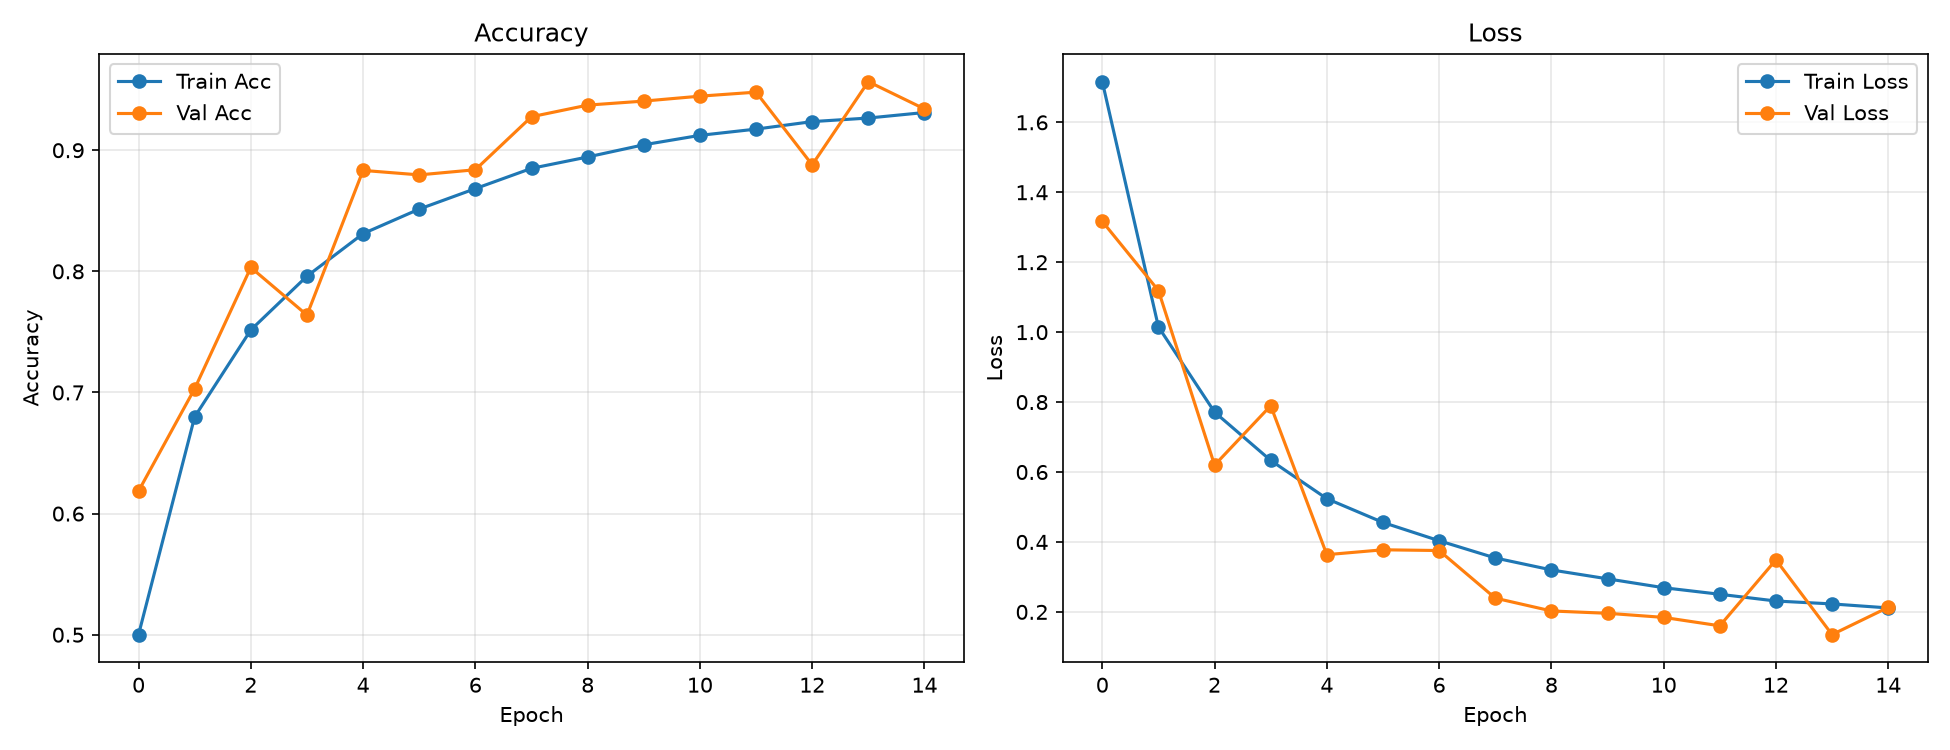

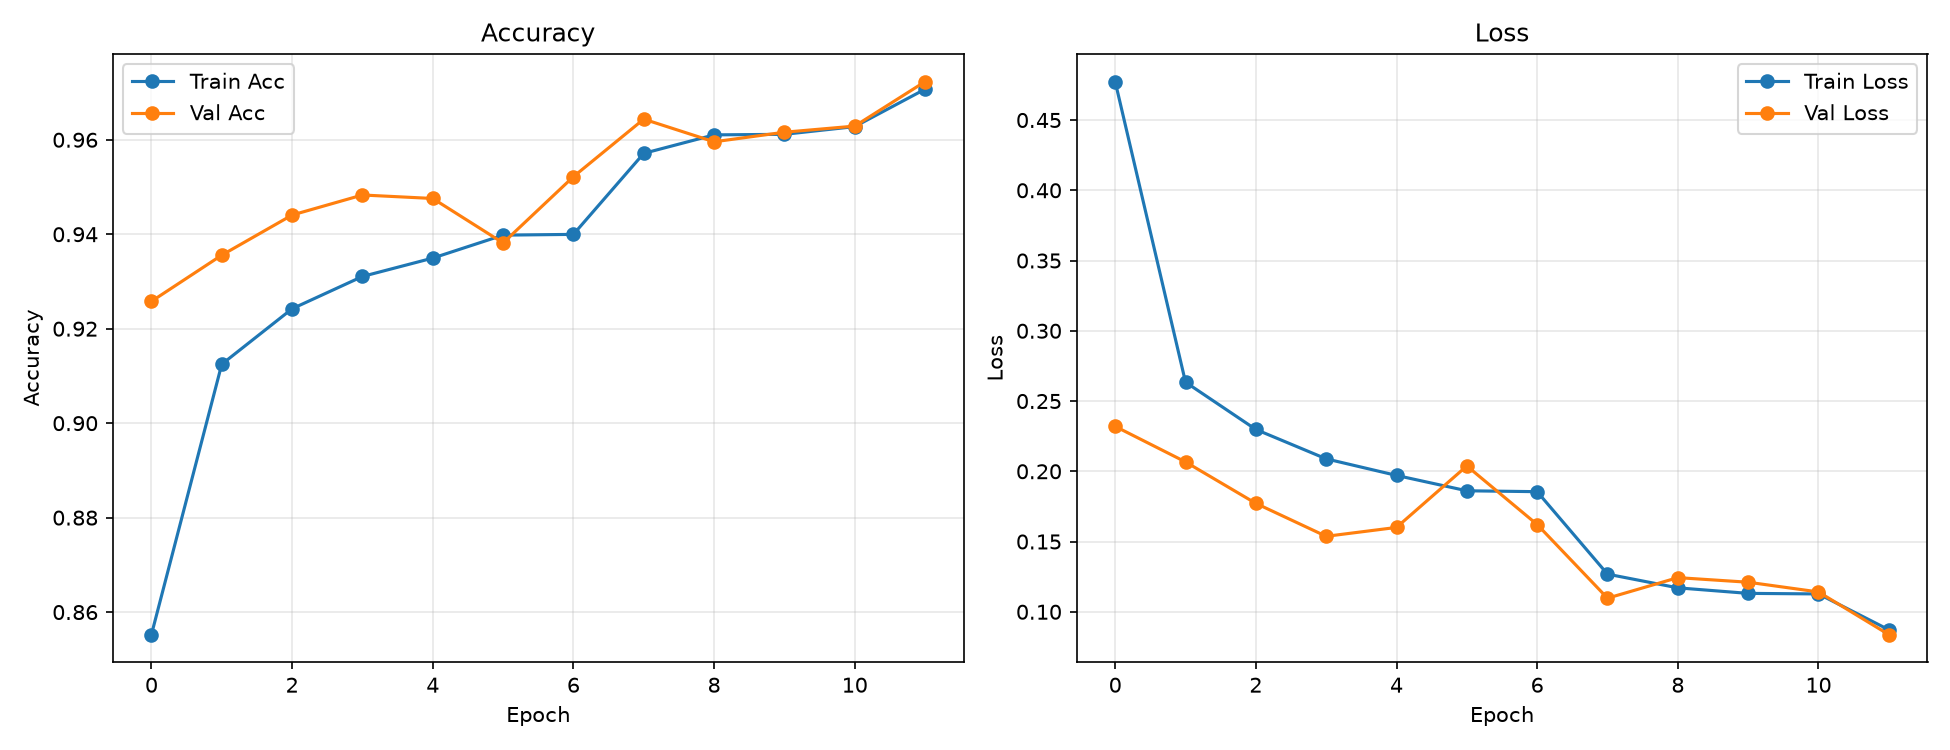

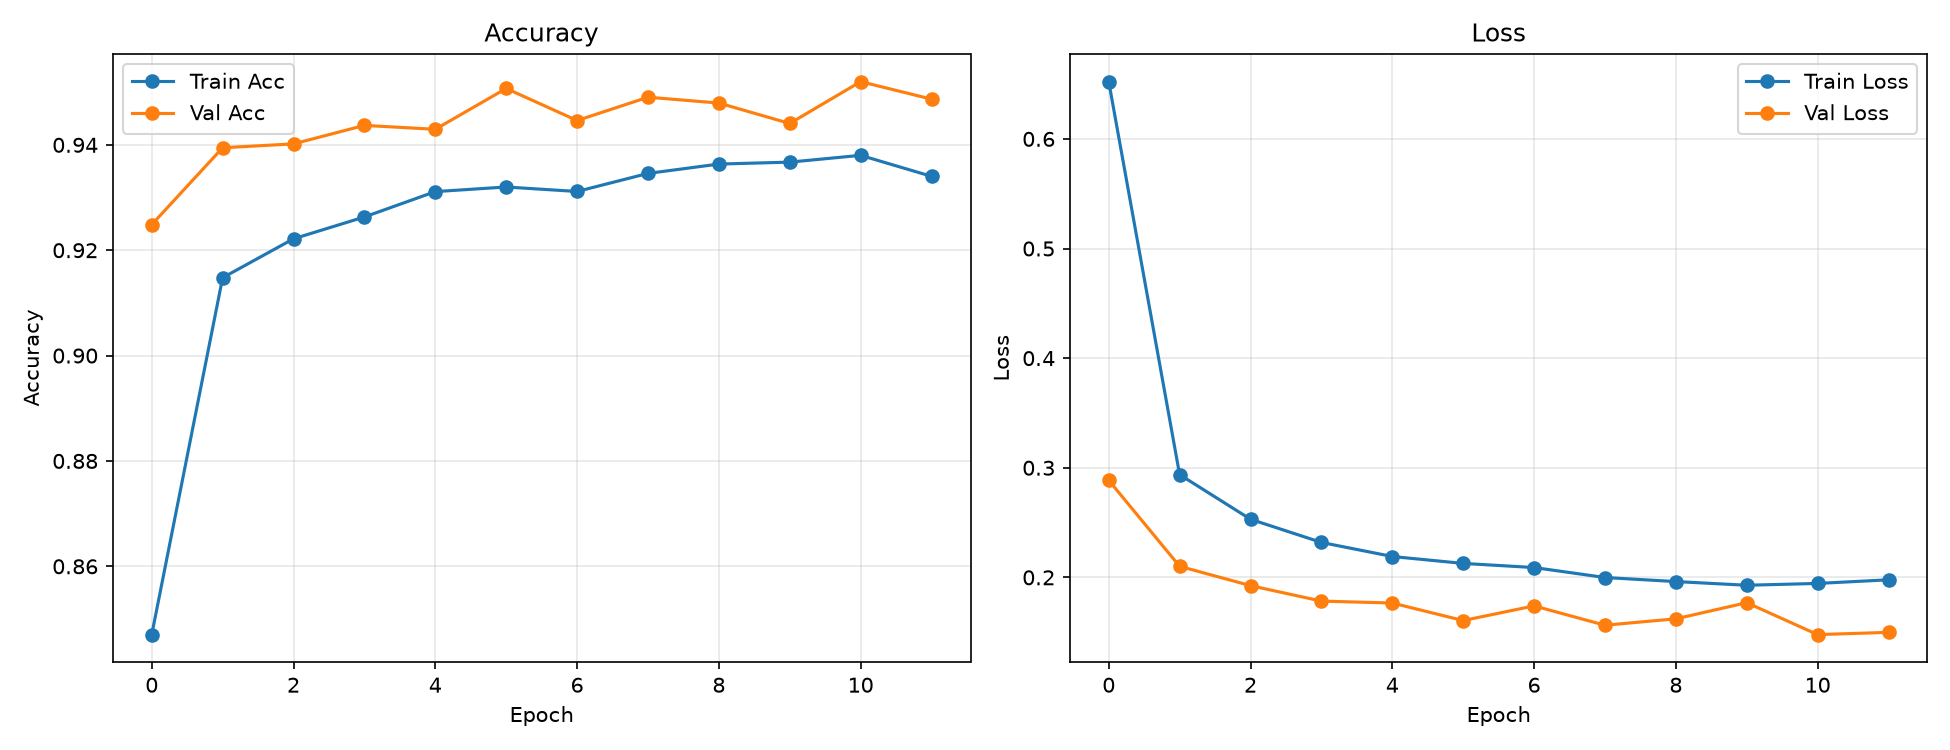

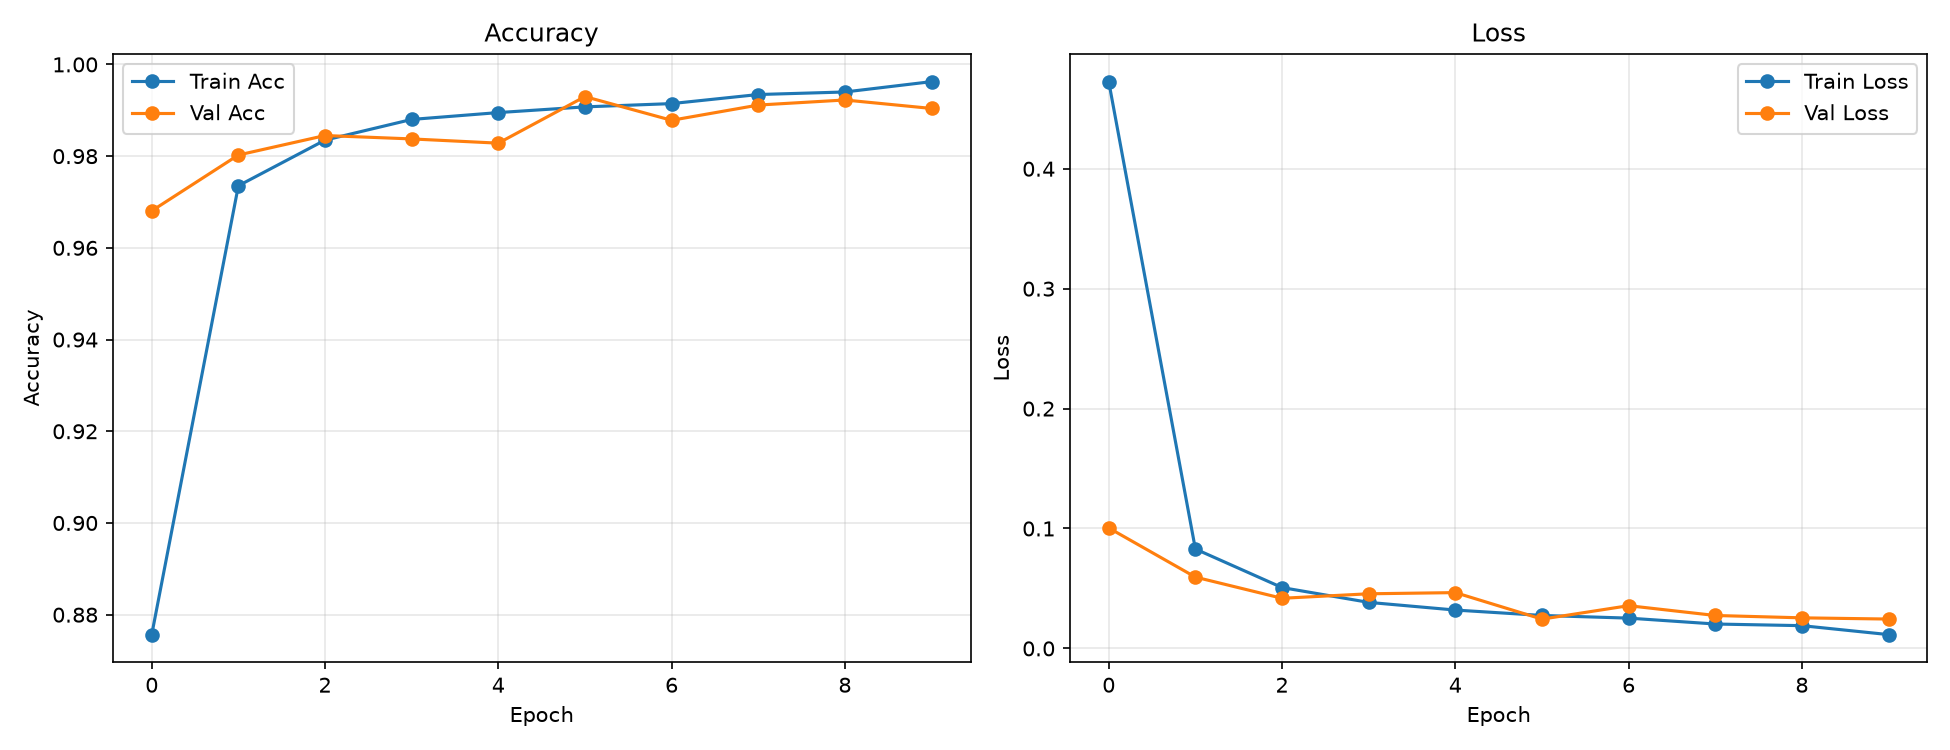

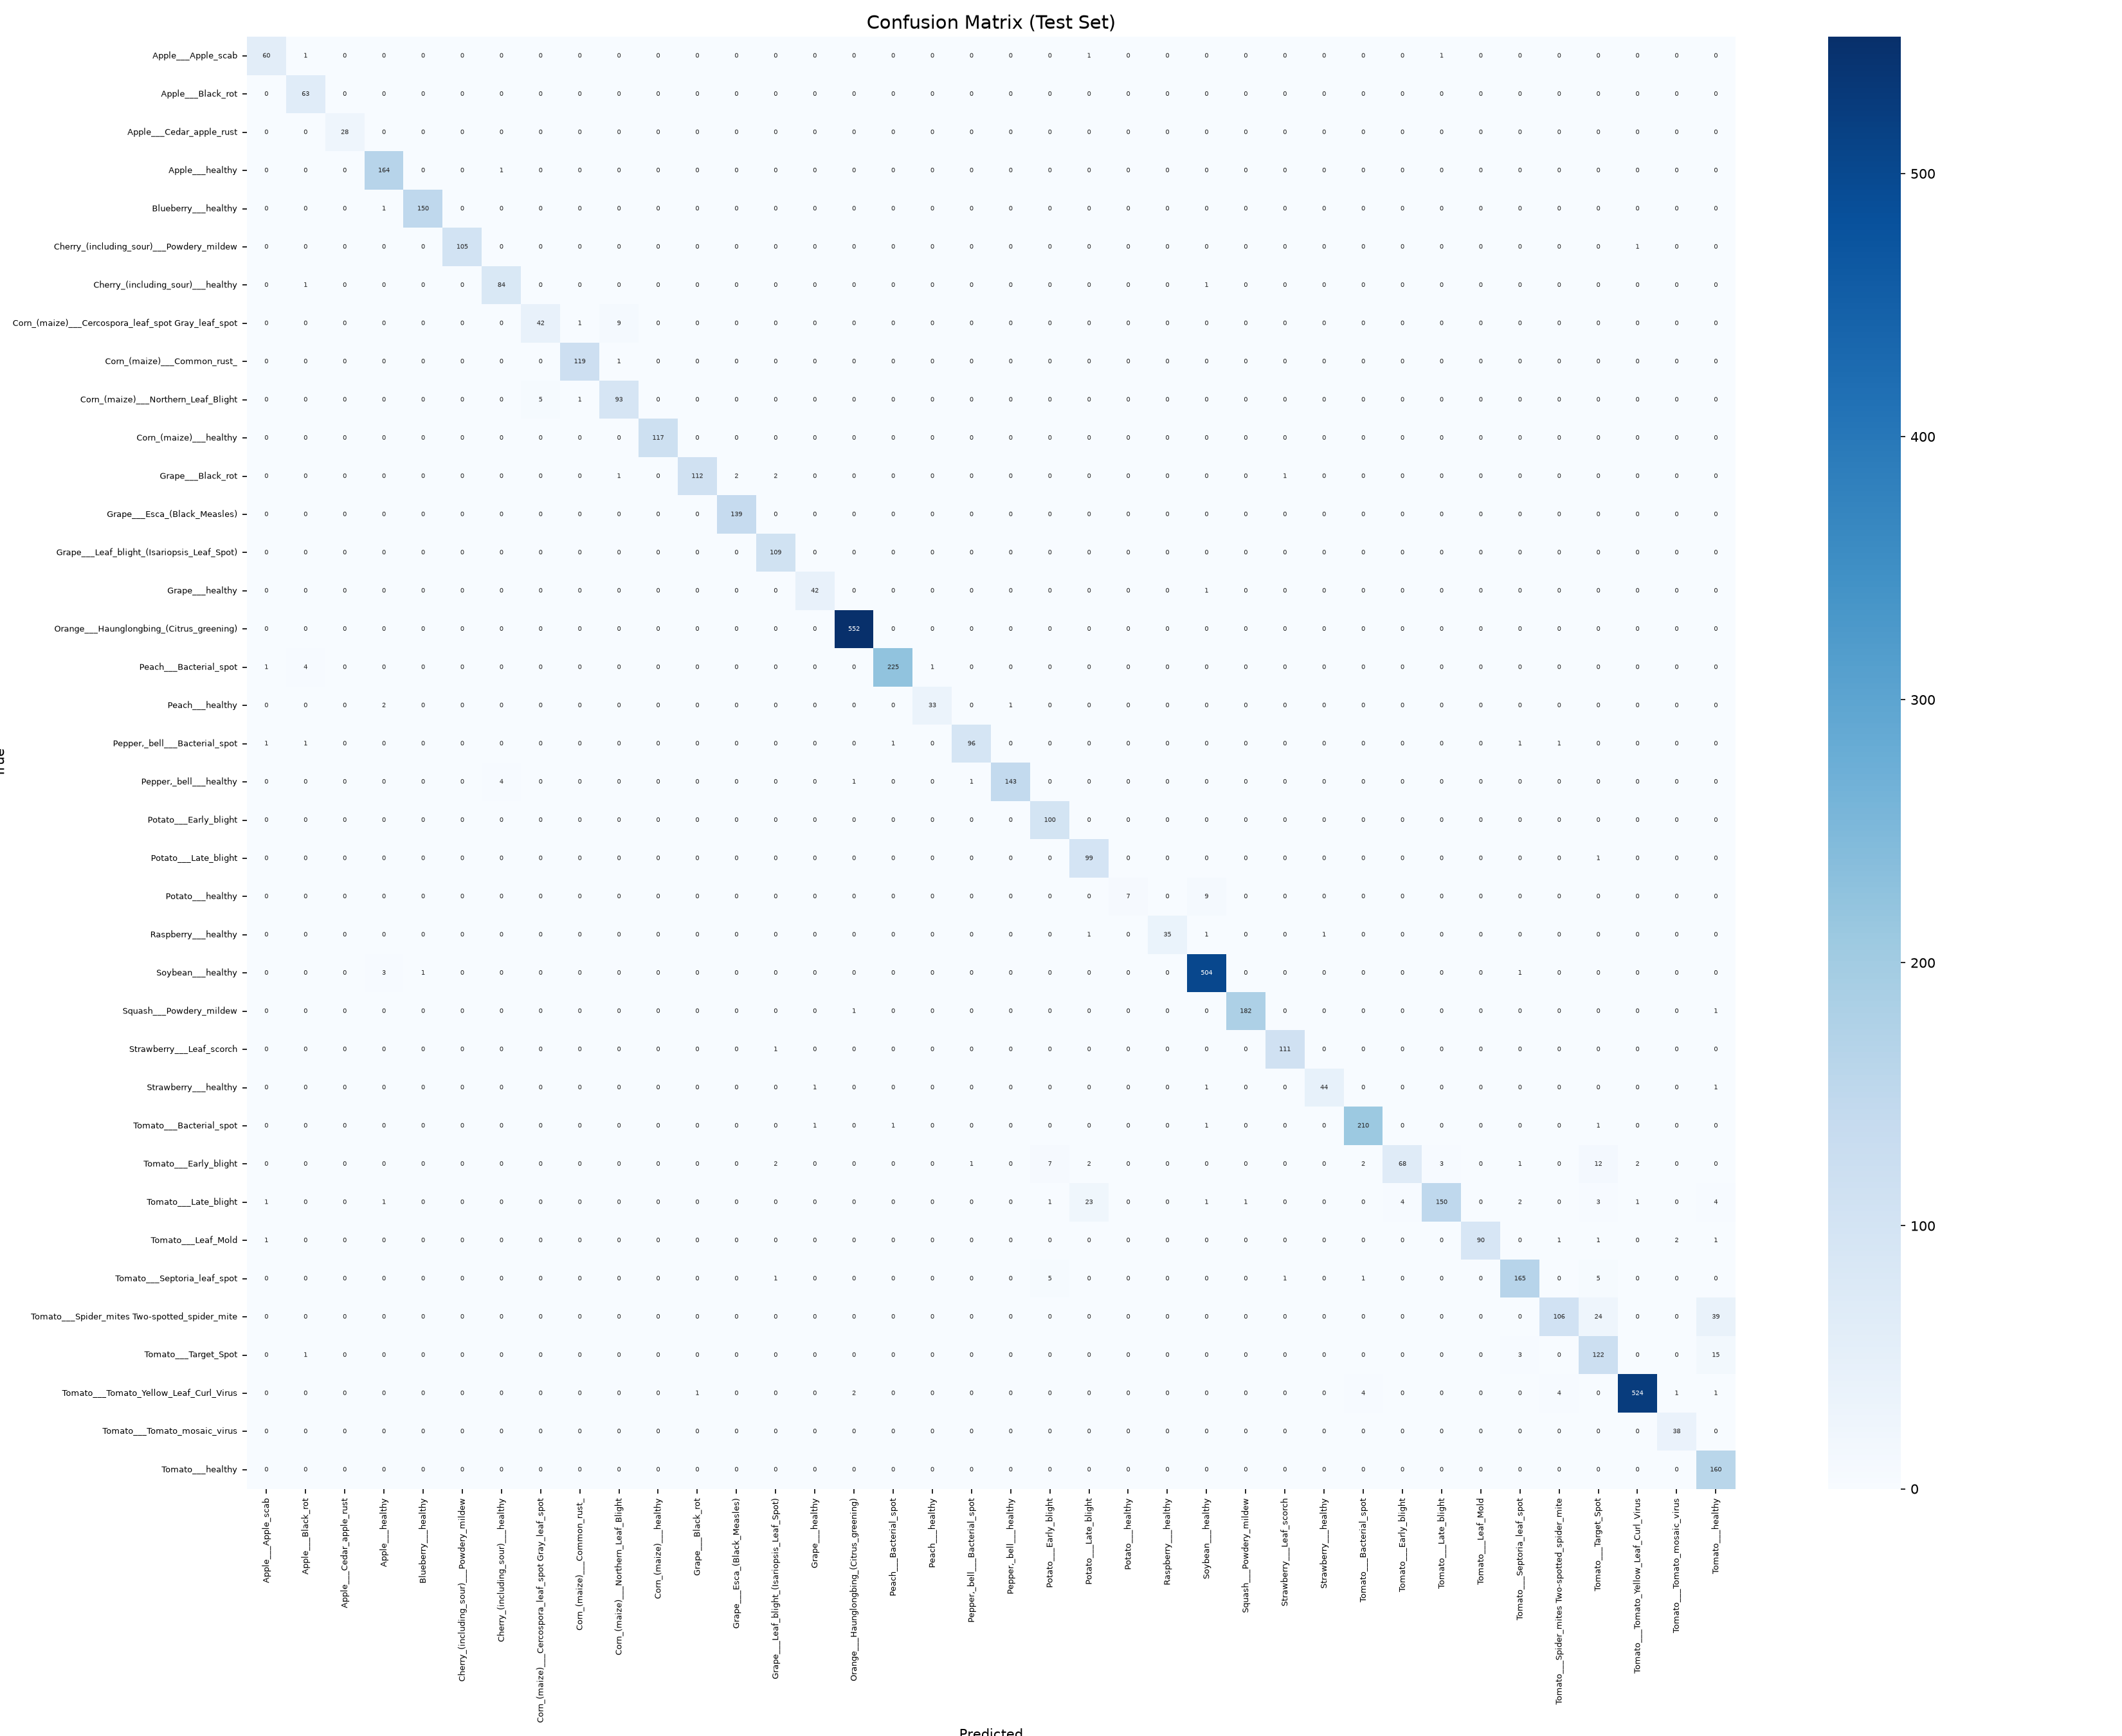

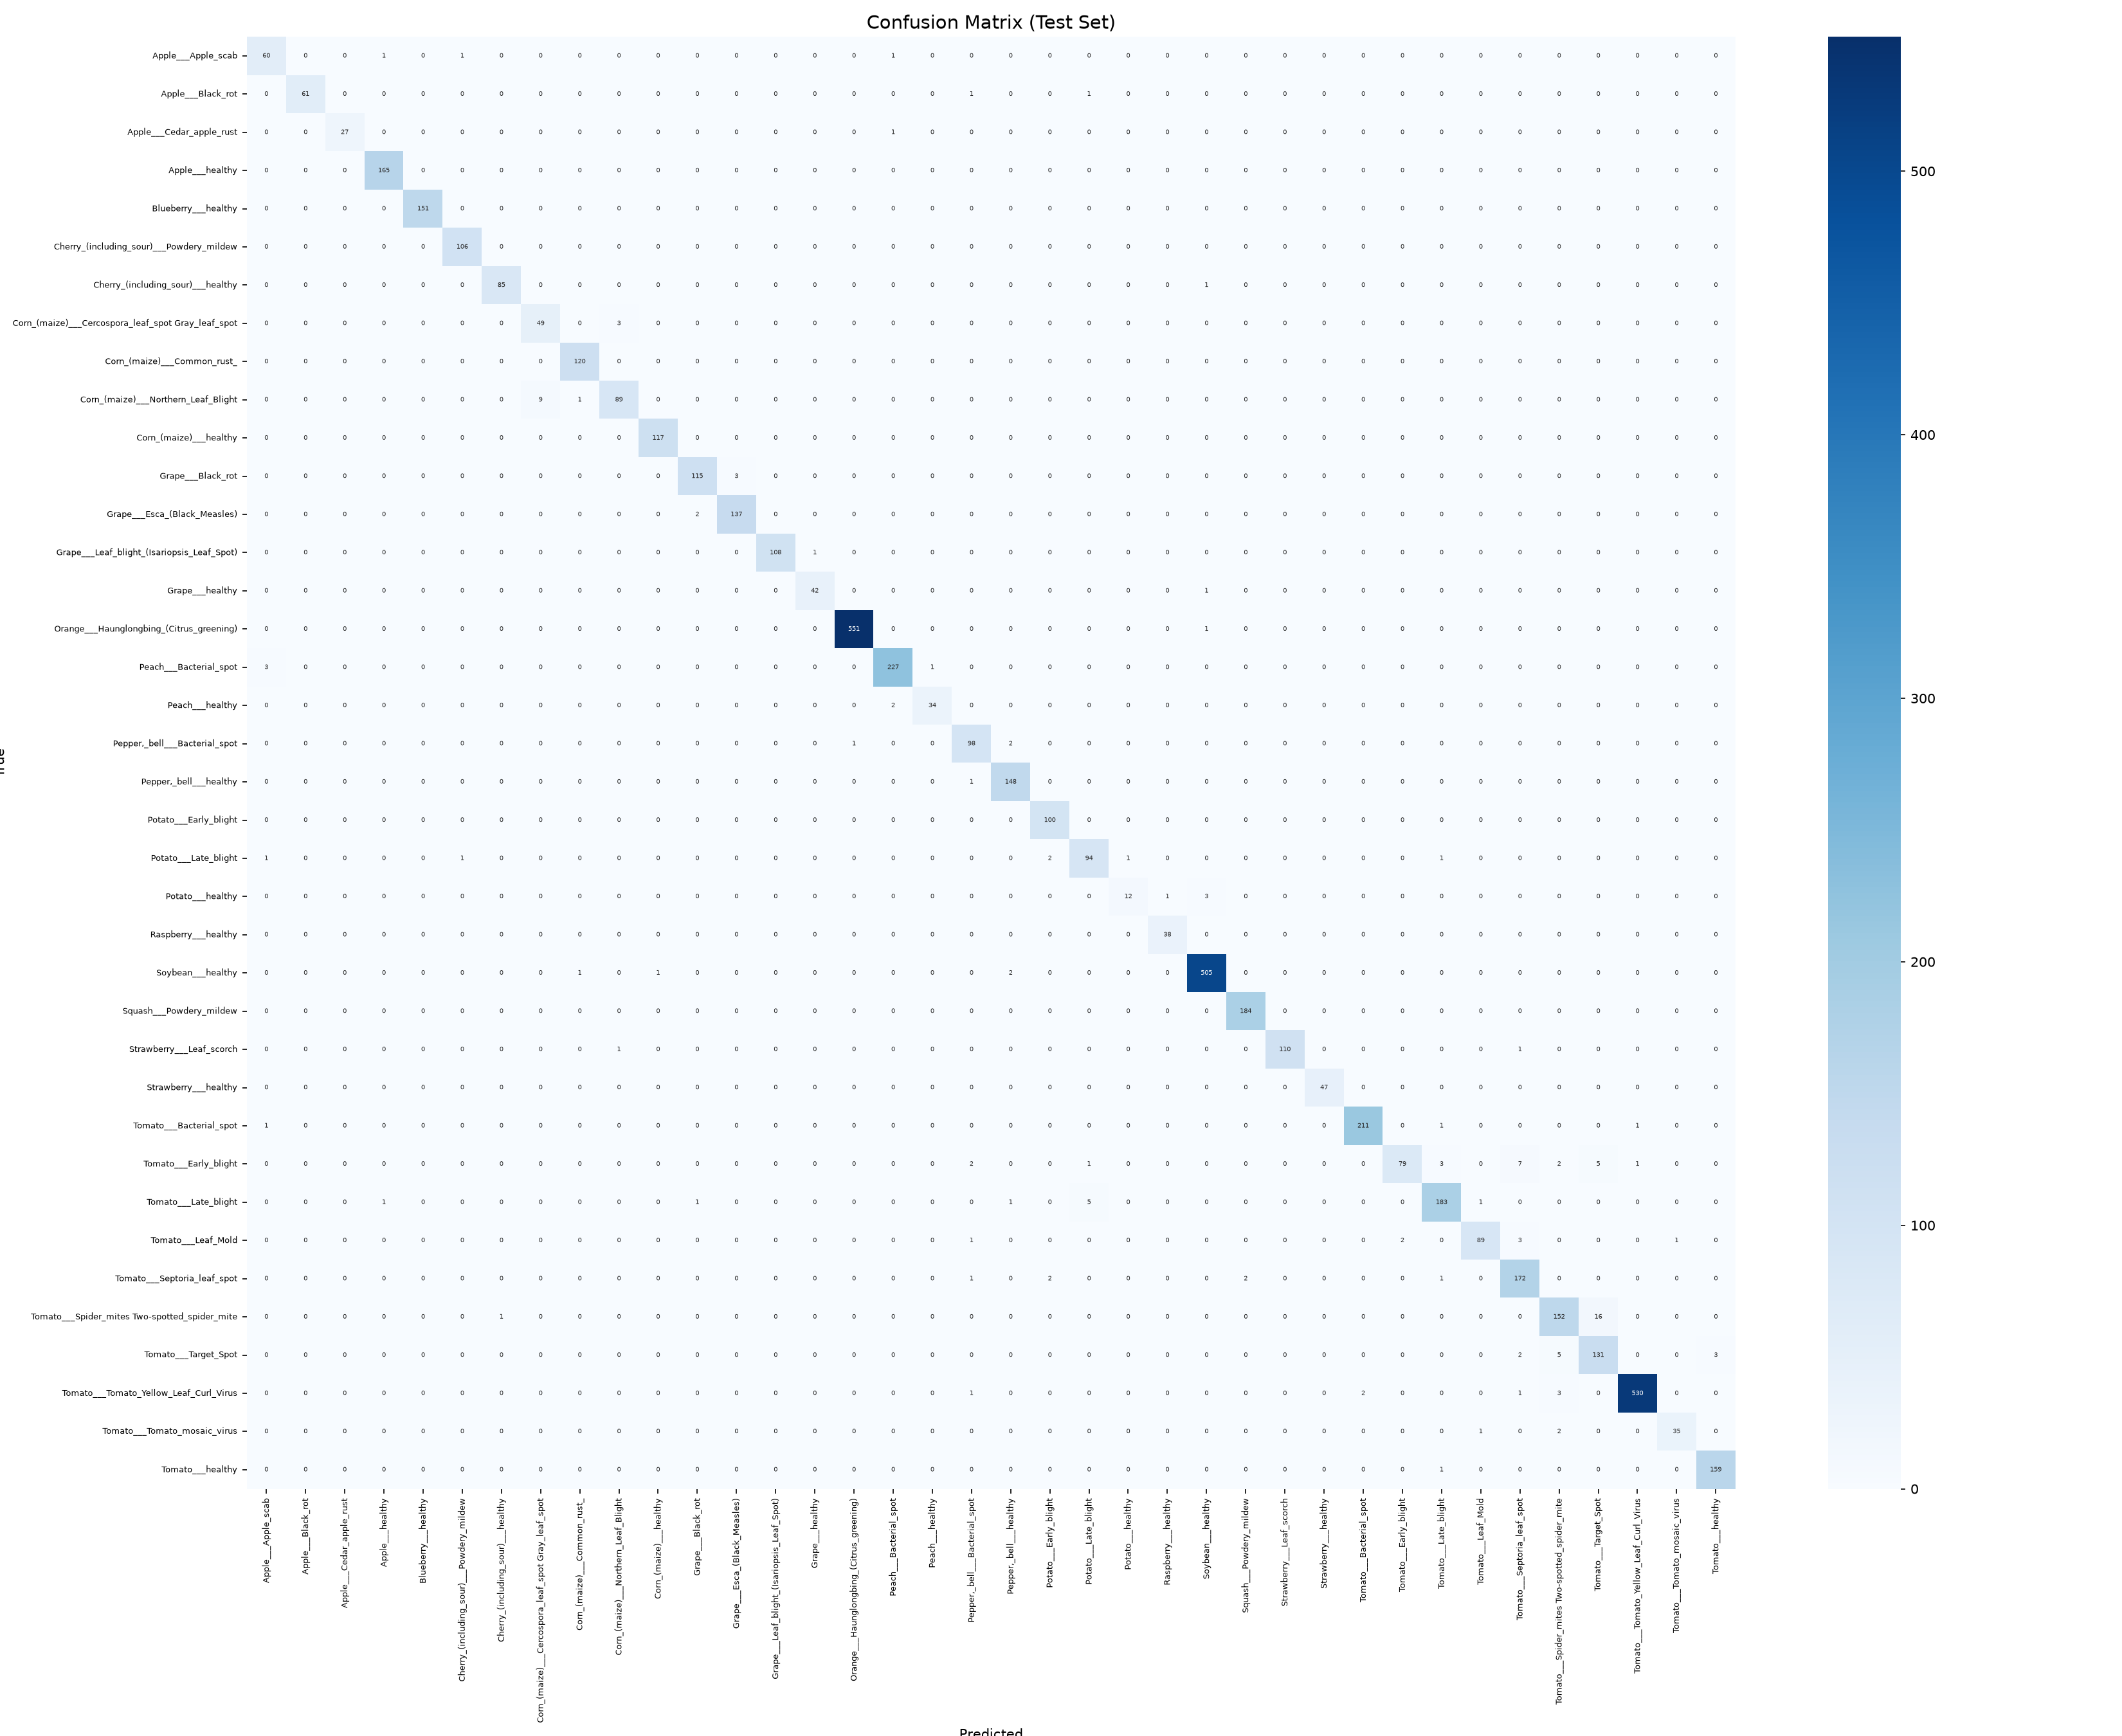

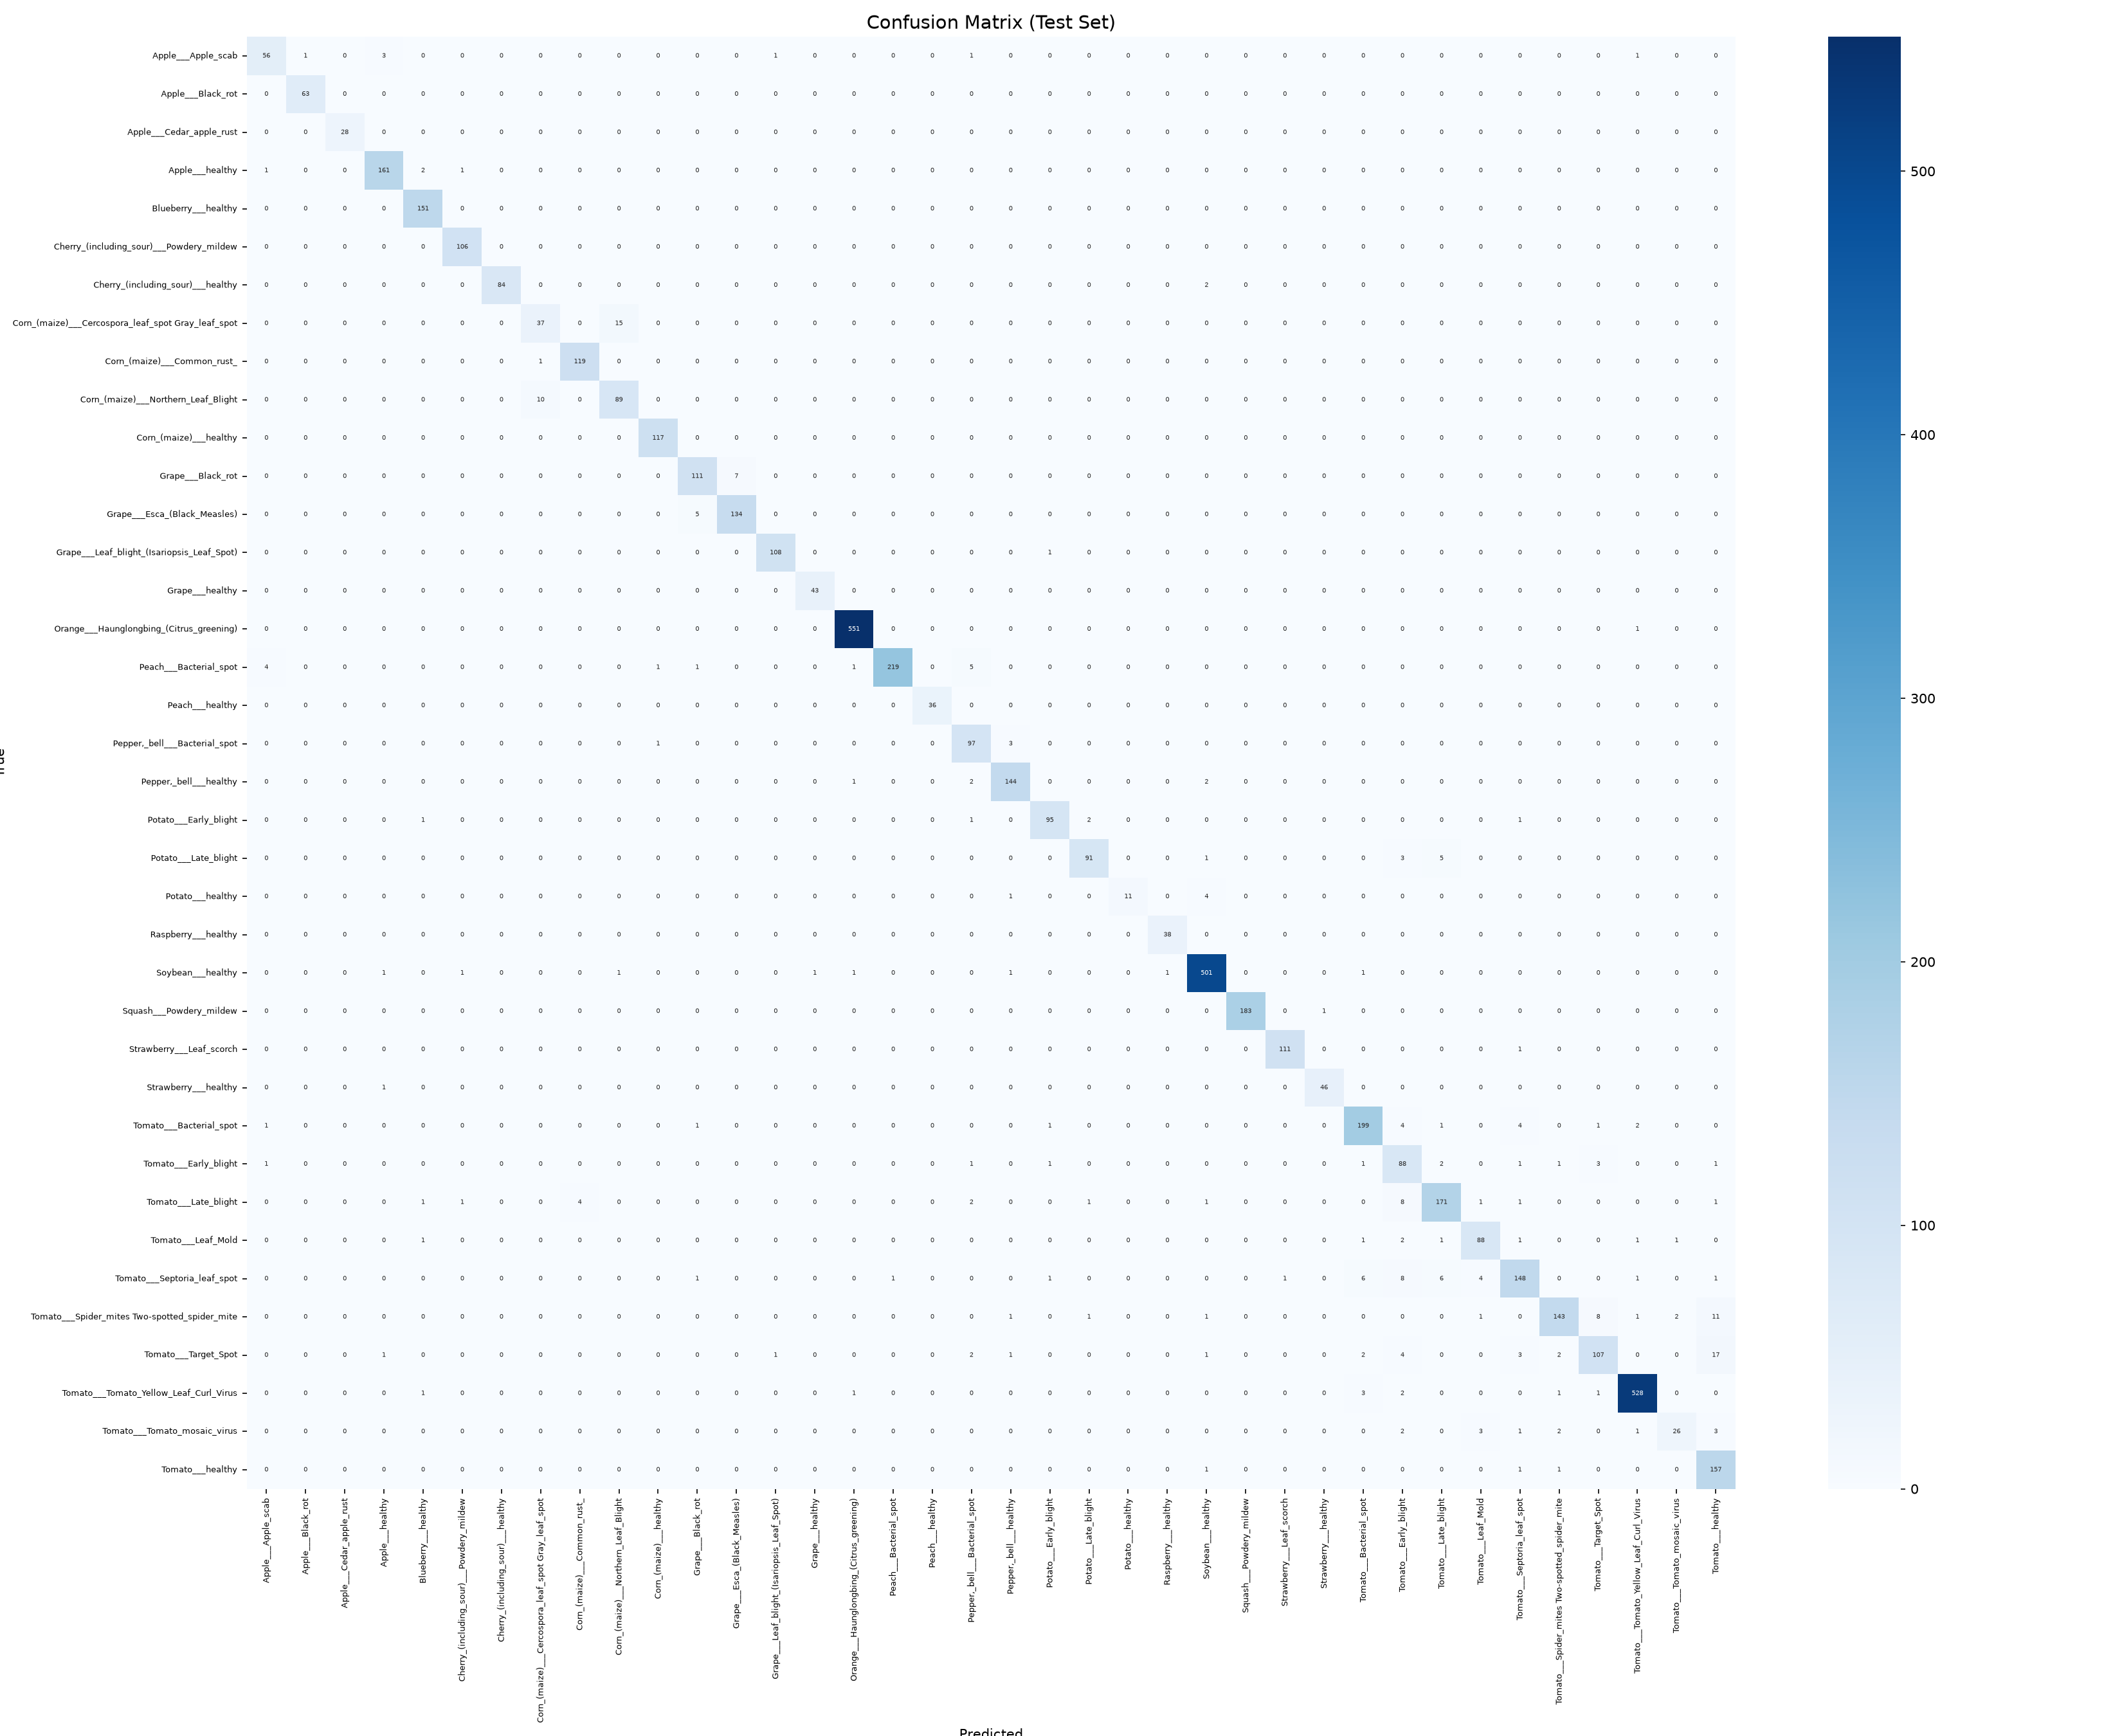

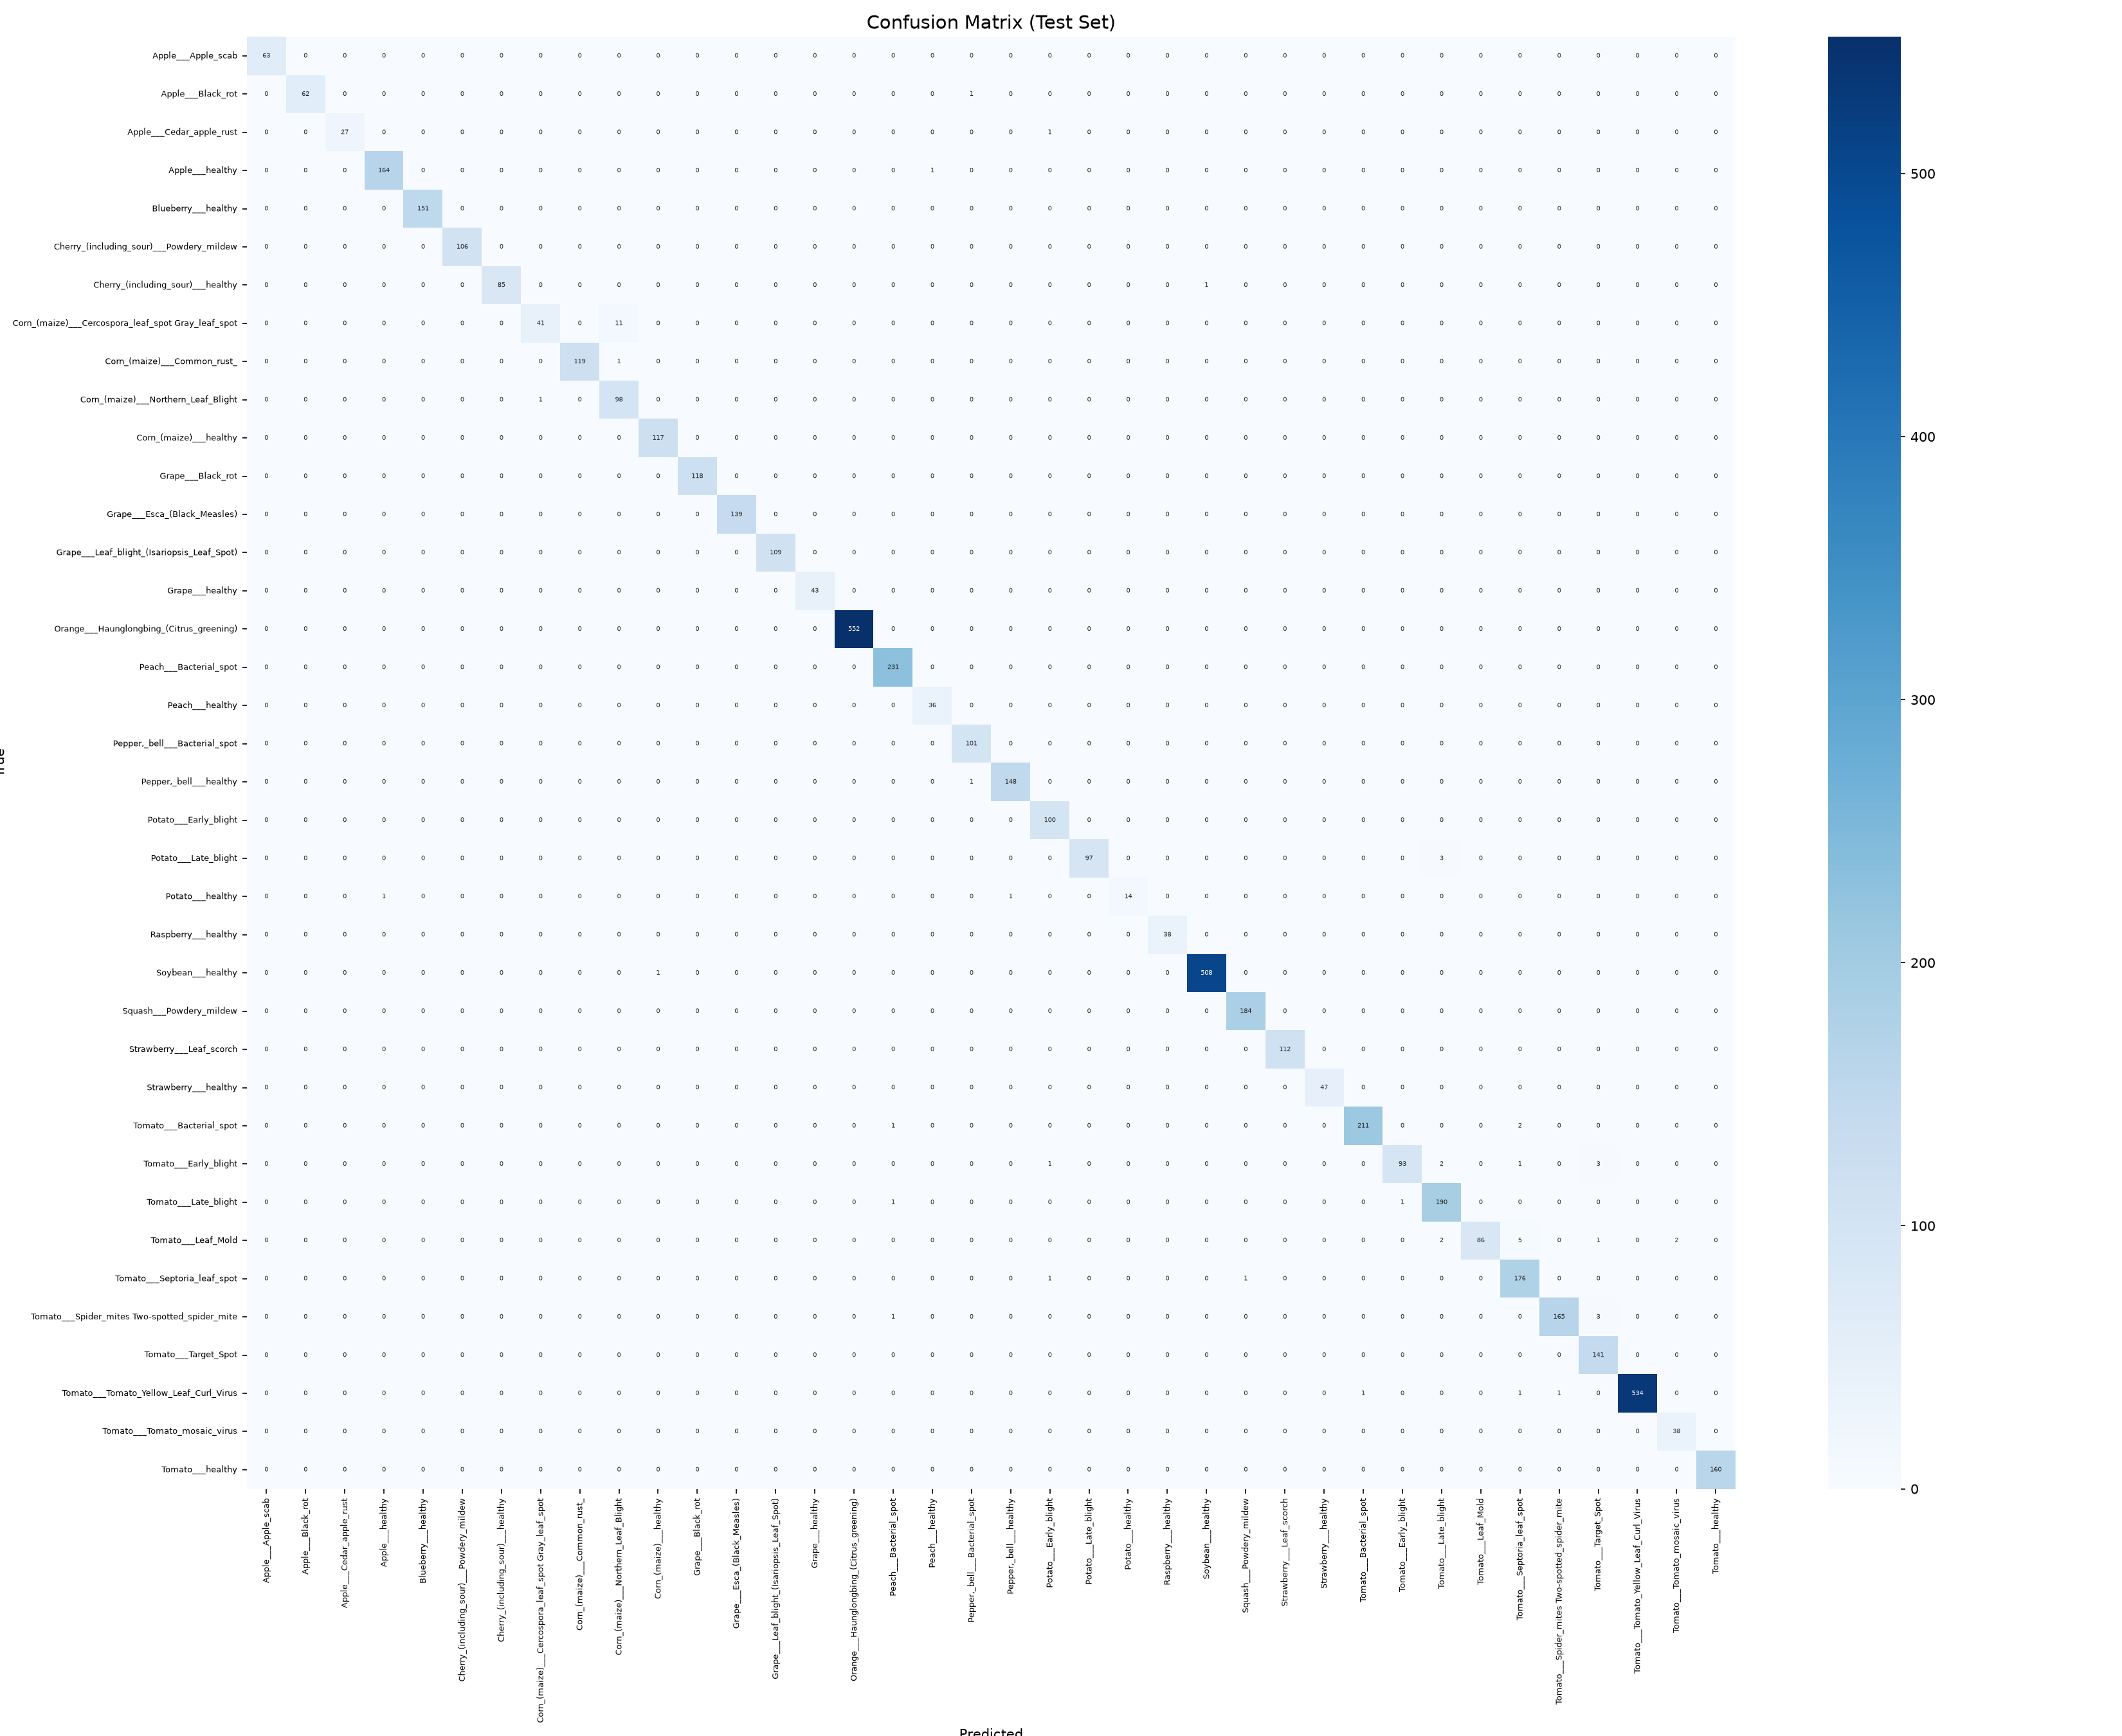

In [8]:
from IPython.display import display, Image as IPImage
for e in ['e1', 'e2', 'e3', 'e4']:
    display(IPImage(filename=f'{OUT_ROOT}/{e}/training_curves.png'))
for e in ['e1', 'e2', 'e3', 'e4']:
    display(IPImage(filename=f'{OUT_ROOT}/{e}/confusion_matrix.png'))

## 9. Error Analysis

In [9]:
info = json.load(open(f'{OUT_ROOT}/e2/per_class_analysis.json'))
print('=== 10 kelas TERBURUK (E2 — untuk analisis kesalahan) ===')
for x in info['worst']:
    print(f"  {x['class']}: {x['acc']:.4f}")

print('\n=== Top-10 misclassification paling yakin (E2) ===')
errs = json.load(open(f'{OUT_ROOT}/e2/top_errors.json'))
for i, e in enumerate(errs[:10], 1):
    print(f"{i:2d}. true={e['true'][:32]:32s} pred={e['pred'][:32]:32s} conf={e['confidence']:.3f}")

=== 10 kelas TERBURUK (E2 — untuk analisis kesalahan) ===
  Potato___healthy: 0.7500
  Tomato___Early_blight: 0.7900
  Corn_(maize)___Northern_Leaf_Blight: 0.8990
  Tomato___Spider_mites Two-spotted_spider_mite: 0.8994
  Tomato___Tomato_mosaic_virus: 0.9211
  Tomato___Leaf_Mold: 0.9271
  Tomato___Target_Spot: 0.9291
  Potato___Late_blight: 0.9400
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 0.9423
  Peach___healthy: 0.9444

=== Top-10 misclassification paling yakin (E2) ===
 1. true=Tomato___Bacterial_spot          pred=Apple___Apple_scab               conf=0.265
 2. true=Tomato___Early_blight            pred=Tomato___Septoria_leaf_spot      conf=0.310
 3. true=Orange___Haunglongbing_(Citrus_g pred=Soybean___healthy                conf=0.326
 4. true=Potato___Late_blight             pred=Cherry_(including_sour)___Powder conf=0.342
 5. true=Apple___Black_rot                pred=Potato___Late_blight             conf=0.397
 6. true=Strawberry___Leaf_scorch         pred=Tomato___S

**Interpretasi:** Kesalahan terkonsentrasi pada kelompok penyakit bercak daun tomat
(Early blight 68,00\%, Spider mites 89,94\%, Late blight 92,19\%) yang memiliki kemiripan
visual tinggi. Confusi dominan: Early blight → Septoria leaf spot, Early blight →
Bacterial spot, Spider mites ↔ Target Spot. Model E4 (fine-tune) menekan error ini hingga
hampir nol (accuracy 99,62\%).

## 10. Kesimpulan

In [10]:
print('RINGKASAN FINAL PROJECT')
print('=' * 50)
for _, r in df.iterrows():
    print(f"{r['Exp']}: {r['Model'][:28]:28s} Acc={r['Acc']:.4f} F1={r['F1']:.4f} ({r['Strategi']})")
print('=' * 50)
print('Kesimpulan:')
print('1. MobileNetV3-Small fine-tune (E4) terbaik: Acc 99.62%, F1 99.38%')
print('2. Fine-tune penuh +2.48 poin vs backbone frozen (E2: 97.14%)')
print('3. CNN dari nol (E1: 95.95%) > EfficientNet frozen (E3: 95.00%) →')
print('   jumlah parameter trainable > ukuran arsitektur pada dataset besar')
print('4. Error dominan: kelas penyakit bercak daun tomat yang mirip visual')
print('5. Tidak ada overfitting signifikan (early stopping + ReduceLROnPlateau)')

RINGKASAN FINAL PROJECT
E1: e1_custom_cnn                Acc=0.9509 F1=0.9339 (Custom CNN baseline (from scratch))
E2: e2_mobilenetv3               Acc=0.9747 F1=0.9641 (MobileNetV3-Small TL, backbone frozen)
E3: e3_efficientnet              Acc=0.9498 F1=0.9348 (EfficientNet-B0 TL, backbone frozen)
E4: e4_mobilenetv3_ft            Acc=0.9899 F1=0.9842 (MobileNetV3-Small TL, fine-tune penuh)
Kesimpulan:
1. MobileNetV3-Small fine-tune (E4) terbaik: Acc 99.62%, F1 99.38%
2. Fine-tune penuh +2.48 poin vs backbone frozen (E2: 97.14%)
3. CNN dari nol (E1: 95.95%) > EfficientNet frozen (E3: 95.00%) →
   jumlah parameter trainable > ukuran arsitektur pada dataset besar
4. Error dominan: kelas penyakit bercak daun tomat yang mirip visual
5. Tidak ada overfitting signifikan (early stopping + ReduceLROnPlateau)


---
*Seluruh angka, gambar, dan log di notebook ini berasal dari eksekusi nyata di GPU lokal
(NVIDIA RTX 4060). Skrip pendukung: `v2/scripts/` · Bukti tambahan: `v2/results/run_all.log`
· Paper: `paper/452024611053-Farrel Ghozy Affifudin.pdf`*